# Setup do arquivo

## 1. Setup do ambiente

Instala o `pysus`, que baixa e converte os
arquivos do DATASUS e os pacotes necessários.


In [1]:
!pip install readdbc dbfread
!pip install "numpy<2.3"

import os
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("[INFO] Ambiente de trabalho configurado.")

[INFO] Ambiente de trabalho configurado.


---
## 2. Dicionário de dados

A célula abaixo grava o arquivo `sinan_dic.py` no ambiente do Colab.

Transcrito do **Dicionário de Dados SINAN NET 5.1**

In [2]:
%%writefile sinan_dic.py
"""
Dicionário de dados — SINAN / Violência Interpessoal e Autoprovocada
"""

YES_NO = {"1": "Sim", "2": "Não", "9": "Ignorado"}
YES_NO_NA = {"1": "Sim", "2": "Não", "8": "Não se aplica", "9": "Ignorado"}

LABELS = {
    # --- notificação ---
    "SG_UF_NOT": "UF de notificação",

    # --- vítima ---
    "NU_IDADE_N": "Idade (codificada)",
    "CS_SEXO": "Sexo",
    "CS_RACA": "Raça/cor",
    "CS_ESCOL_N": "Escolaridade",
    "SIT_CONJUG": "Situação conjugal",

    # --- residência ---
    "SG_UF": "UF de residência",

    # --- deficiência e transtorno ---
    "DEF_TRANS": "Possui deficiência ou transtorno",
    "DEF_FISICA": "Deficiência física",
    "DEF_MENTAL": "Deficiência intelectual",
    "DEF_VISUAL": "Deficiência visual",
    "DEF_AUDITI": "Deficiência auditiva",
    "TRAN_MENT": "Transtorno mental",
    "TRAN_COMP": "Transtorno de comportamento",
    "DEF_OUT": "Outras deficiências ou síndromes",

    # --- ocorrência ---
    "SG_UF_OCOR": "UF de ocorrência",
    "LOCAL_OCOR": "Local de ocorrência",

    # --- caracterização da violência ---
    "OUT_VEZES": "Violência de repetição",
    "LES_AUTOP": "Lesão autoprovocada",
    "VIOL_MOTIV": "Violência motivada por",
    "VIOL_FISIC": "Violência física",
    "VIOL_PSICO": "Violência psicológica/moral",
    "VIOL_TORT": "Tortura",
    "VIOL_SEXU": "Violência sexual",
    "VIOL_TRAF": "Tráfico de seres humanos",
    "VIOL_FINAN": "Violência financeira/econômica",
    "VIOL_NEGLI": "Negligência/abandono",
    "VIOL_LEGAL": "Intervenção legal",
    "VIOL_OUTR": "Outro tipo de violência",

    # --- meio de agressão ---
    "AG_FORCA": "Meio — força corporal/espancamento",
    "AG_ENFOR": "Meio — enforcamento",
    "AG_OBJETO": "Meio — objeto contundente",
    "AG_CORTE": "Meio — objeto perfurocortante",
    "AG_QUENTE": "Meio — substância/objeto quente",
    "AG_ENVEN": "Meio — envenenamento/intoxicação",
    "AG_FOGO": "Meio — arma de fogo",
    "AG_AMEACA": "Meio — ameaça",
    "AG_OUTROS": "Meio — outro",

    # --- provável autor ---
    "NUM_ENVOLV": "Número de envolvidos",
    "REL_PAI": "Autor — pai",
    "REL_MAE": "Autor — mãe",
    "REL_PAD": "Autor — padrasto",
    "REL_MAD": "Autor — madrasta",
    "REL_CONJ": "Autor — cônjuge",
    "REL_EXCON": "Autor — ex-cônjuge",
    "REL_NAMO": "Autor — namorado(a)",
    "REL_EXNAM": "Autor — ex-namorado(a)",
    "REL_FILHO": "Autor — filho(a)",
    "REL_IRMAO": "Autor — irmão(ã)",
    "REL_CONHEC": "Autor — amigo/conhecido",
    "REL_DESCO": "Autor — desconhecido",
    "REL_CUIDA": "Autor — cuidador",
    "REL_PATRAO": "Autor — patrão/chefe",
    "REL_INST": "Autor — relação institucional",
    "REL_POL": "Autor — policial/agente da lei",
    "REL_PROPRI": "Autor — a própria pessoa",
    "REL_OUTROS": "Autor — outros",
    "AUTOR_SEXO": "Sexo do provável autor",
    "AUTOR_ALCO": "Suspeita de uso de álcool pelo autor",
}

CATEGORIES = {
    "CS_SEXO": {"M": "Masculino", "F": "Feminino", "I": "Ignorado"},

    "CS_RACA": {
        "1": "Branca", "2": "Preta", "3": "Amarela",
        "4": "Parda", "5": "Indígena", "9": "Ignorado",
    },


    "CS_ESCOL_N": {
        "0": "Analfabeto",
        "1": "1ª a 4ª série incompleta do EF",
        "2": "4ª série completa do EF",
        "3": "5ª a 8ª série incompleta do EF",
        "4": "Ensino fundamental completo",
        "5": "Ensino médio incompleto",
        "6": "Ensino médio completo",
        "7": "Educação superior incompleta",
        "8": "Educação superior completa",
        "9": "Ignorado",
        "10": "Não se aplica",
    },

    "SIT_CONJUG": {
        "1": "Solteiro", "2": "Casado/união consensual", "3": "Viúvo",
        "4": "Separado", "8": "Não se aplica", "9": "Ignorado",
    },

    "LOCAL_OCOR": {
        "01": "Residência", "02": "Habitação coletiva", "03": "Escola",
        "04": "Local de prática esportiva", "05": "Bar ou similar",
        "06": "Via pública", "07": "Comércio/serviços",
        "08": "Indústrias/construção", "09": "Outro", "99": "Ignorado",
    },

    "VIOL_MOTIV": {
        "01": "Sexismo",
        "02": "Homofobia/lesbofobia/bifobia/transfobia",
        "03": "Racismo",
        "04": "Intolerância religiosa",
        "05": "Xenofobia",
        "06": "Conflito geracional",
        "07": "Situação de rua",
        "08": "Deficiência",
        "09": "Outros",
        "88": "Não se aplica",
        "99": "Ignorado",
    },

    "NUM_ENVOLV": {"1": "Um", "2": "Dois ou mais", "9": "Ignorado"},

    "AUTOR_SEXO": {
        "1": "Masculino", "2": "Feminino",
        "3": "Ambos os sexos", "9": "Ignorado",
    },
}

# Campos Sim/Não/Ignorado
_YES_NO_FIELDS = [
    "OUT_VEZES", "DEF_TRANS",
    "VIOL_FISIC", "VIOL_PSICO", "VIOL_TORT", "VIOL_SEXU", "VIOL_TRAF",
    "VIOL_FINAN", "VIOL_NEGLI", "VIOL_LEGAL", "VIOL_OUTR",
    "AG_FORCA", "AG_ENFOR", "AG_OBJETO", "AG_CORTE", "AG_QUENTE",
    "AG_ENVEN", "AG_FOGO", "AG_AMEACA", "AG_OUTROS",
    "REL_PAI", "REL_MAE", "REL_PAD", "REL_MAD", "REL_CONJ", "REL_EXCON",
    "REL_NAMO", "REL_EXNAM", "REL_FILHO", "REL_IRMAO", "REL_CONHEC",
    "REL_DESCO", "REL_CUIDA", "REL_PATRAO", "REL_INST", "REL_POL","REL_PROPRI",
    "REL_OUTROS", "AUTOR_ALCO",
]

# Campos que aceitam "Não se aplica"
_YES_NO_NA_FIELDS = [
    "LES_AUTOP",
    "DEF_FISICA", "DEF_MENTAL", "DEF_VISUAL", "DEF_AUDITI",
    "TRAN_MENT", "TRAN_COMP", "DEF_OUT",
]

for _f in _YES_NO_FIELDS:
    CATEGORIES.setdefault(_f, dict(YES_NO))
for _f in _YES_NO_NA_FIELDS:
    CATEGORIES.setdefault(_f, dict(YES_NO_NA))

# Códigos IBGE de UF
UF_CODE = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB",
    "26": "PE", "27": "AL", "28": "SE", "29": "BA",
    "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "51": "MT", "52": "GO", "53": "DF",
}

UF_NAME = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas",
    "BA": "Bahia", "CE": "Ceará", "DF": "Distrito Federal",
    "ES": "Espírito Santo", "GO": "Goiás", "MA": "Maranhão",
    "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco",
    "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul", "RO": "Rondônia", "RR": "Roraima",
    "SC": "Santa Catarina", "SP": "São Paulo", "SE": "Sergipe",
    "TO": "Tocantins",
}


ATRIBUTOS_PROTEGIDOS = ["CS_RACA", "CS_SEXO"]



Overwriting sinan_dic.py


---
## 3. Configuração

Onde é decidido a idade mínima, o alvo e as colunas relevantes.

In [3]:
YEAR = 2024

MINIMAL_AGE = 60
TARGET = "OUT_VEZES" # Violência de repetição?

# Colunas para processamento
COLUMNS = [
    # --- identificação e alvo ---
    "NU_IDADE_N",
    "OUT_VEZES",
    "SG_UF_OCOR",
    "SG_UF_NOT"
    ,"SG_UF",

    # --- perfil da vítima ---
    "CS_SEXO",
    "CS_RACA",
    "CS_ESCOL_N",
    "SIT_CONJUG",

    # --- deficiência e transtorno ---
    "DEF_TRANS",
    "DEF_FISICA",
    "DEF_MENTAL",
    "DEF_VISUAL",
    "DEF_AUDITI",
    "TRAN_MENT",
    "TRAN_COMP",
    "DEF_OUT",

    # --- contexto da ocorrência ---
    "LOCAL_OCOR",
    "VIOL_MOTIV",
    "LES_AUTOP",

    # --- tipo de violência ---
    "VIOL_FISIC",
    "VIOL_PSICO",
    "VIOL_TORT",
    "VIOL_SEXU",
    "VIOL_TRAF",
    "VIOL_FINAN",
    "VIOL_NEGLI",
    "VIOL_LEGAL",
    "VIOL_OUTR",

    # --- meio de agressão ---
    "AG_FORCA",
    "AG_AMEACA",
    "AG_OBJETO",
    "AG_CORTE",
    "AG_QUENTE",
    "AG_ENFOR",
    "AG_ENVEN",
    "AG_FOGO",
    "AG_OUTROS",

    # --- provável autor ---
    "NUM_ENVOLV",
    "AUTOR_SEXO",
    "AUTOR_ALCO",
    "REL_FILHO",
    "REL_CONJ",
    "REL_EXCON",
    "REL_CUIDA",
    "REL_PAI",
    "REL_MAE",
    "REL_IRMAO",
    "REL_CONHEC",
    "REL_DESCO",
    "REL_INST",
    "REL_PATRAO",
    "REL_POL",
        "REL_PROPRI",
    "REL_NAMO",
    "REL_EXNAM",
    "REL_PAD",
    "REL_MAD",
    "REL_OUTROS",
]

COL_AGE = "NU_IDADE_N"

# Organizando colunas e eliminando duplicatas
COLUMNS = list(dict.fromkeys([COL_AGE, TARGET] + COLUMNS))

# print(f"[DEBUG] Ano: {YEAR} | {len(COLUMNS)} colunas selecionadas")

In [4]:
# Declaração de funções

from sinan_dic import UF_CODE, UF_NAME, LABELS, CATEGORIES

def normalize_code(value):
    """Normalizando valores do .parquet, exemplo: '1', ' 1', 1 ou 1.0 tem que virar o mesmo valor"""
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text or None


---
## 4. Download dos microdados

Via FTP, no DATASUS, em `/dissemin/publicos/SINAN/DADOS/FINAIS/VIOLBR<ano>`. Baixado em .dbc e convertido para .parquet para melhor manuseamento dos dados.


In [5]:
import ftplib
import os
import pyarrow.parquet as parq
import pandas as pd
import readdbc
from dbfread import DBF

# Função alternativa por conta de conflito do PySus

def download_sinan_viol(year):
    ftp = ftplib.FTP('ftp.datasus.gov.br')
    ftp.login()

    decade = str(year)[-2:] # Pega os 2 últimos dígitos

    ftp.cwd('/dissemin/publicos/SINAN/DADOS/FINAIS/')

    files = ftp.nlst()
    files_viol = [f for f in files if f.startswith('VIOL') and f.endswith(f'{decade}.dbc')]

    dataframes = []

    for file in files_viol:
        dbc_path = f'/content/{file}'
        dbf_path = f'/content/{file.replace(".dbc", ".dbf")}'

        # Baixa do FTP
        with open(dbc_path, 'wb') as f:
            ftp.retrbinary(f'RETR {file}', f.write)

        # Converte pra DBF
        readdbc.dbc2dbf(dbc_path, dbf_path)

        # Lê pro Pandas
        table = DBF(dbf_path, encoding='latin1')
        df_state = pd.DataFrame(iter(table))
        dataframes.append(df_state)

        os.remove(dbc_path)
        os.remove(dbf_path)

    ftp.quit()

    # Junta todos os estados e e salva em um arquivo parquet
    merged = pd.concat(dataframes, ignore_index=True)
    path_parquet = f'/content/VIOL_{year}.parquet'
    merged.to_parquet(path_parquet)

    return [path_parquet]



In [6]:
# Download

print(f"[INFO] Iniciando download de SINAL/VIOL edição {YEAR}.")

paths = download_sinan_viol(YEAR)

filename = str(paths[0]) if isinstance(paths, list) else str(paths)

print(f"[INFO] Download concluído com sucesso.")

# Validando arquivo
file = parq.ParquetFile(filename)

file_cols = list(file.schema_arrow.names)

missing = [c for c in COLUMNS if c not in file_cols]
if missing:
    print(f"[AVISO] ATENÇÃO — não existem neste arquivo: {missing}")
    COLUMNS = [c for c in COLUMNS if c in file_cols]

raw_data = pd.read_parquet(filename, columns=COLUMNS)

# print(f"[DEBUG] Carregado: {raw_data.shape[0]:,} linhas x {raw_data.shape[1]} colunas")

raw_data.head(1)

[INFO] Iniciando download de SINAL/VIOL edição 2024.
[INFO] Download concluído com sucesso.


,NU_IDADE_N,OUT_VEZES,SG_UF_OCOR,SG_UF_NOT,SG_UF,CS_SEXO,CS_RACA,CS_ESCOL_N,SIT_CONJUG,DEF_TRANS,DEF_FISICA,DEF_MENTAL,DEF_VISUAL,DEF_AUDITI,TRAN_MENT,TRAN_COMP,DEF_OUT,LOCAL_OCOR,VIOL_MOTIV,LES_AUTOP,VIOL_FISIC,VIOL_PSICO,VIOL_TORT,VIOL_SEXU,VIOL_TRAF,VIOL_FINAN,VIOL_NEGLI,VIOL_LEGAL,VIOL_OUTR,AG_FORCA,AG_AMEACA,AG_OBJETO,AG_CORTE,AG_QUENTE,AG_ENFOR,AG_ENVEN,AG_FOGO,AG_OUTROS,NUM_ENVOLV,AUTOR_SEXO,AUTOR_ALCO,REL_FILHO,REL_CONJ,REL_EXCON,REL_CUIDA,REL_PAI,REL_MAE,REL_IRMAO,REL_CONHEC,REL_DESCO,REL_INST,REL_PATRAO,REL_POL,REL_PROPRI,REL_NAMO,REL_EXNAM,REL_PAD,REL_MAD,REL_OUTROS
0,4033,1,52,52,52,F,4,09,2,2,8,8,8,8,8,8,8,01,09,2,2,1,2,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,1,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


---
## 5. Filtrar vítimas 60+

Decodificar idade e filtrar apenas pessoas com 60+

### Dicionário

| 1º dígito | Unidade |
|---|---|
| 1 | horas |
| 2 | dias |
| 3 | meses |
| 4 | anos |


In [7]:
age_encoded = pd.to_numeric(raw_data[COL_AGE], errors="coerce")
unit = age_encoded // 1000
quantity = age_encoded % 1000

# Só é idade de interesse quando a unidade é anos
raw_data["Idade"] = quantity.where(unit == 4)

# Filtrando apenas idosos
elderly = raw_data[raw_data["Idade"] >= MINIMAL_AGE].copy()
test = elderly
raw_data["Idade"] = raw_data["Idade"].astype("Int64")

print(f"Total de notificações no ano : {len(raw_data):,}")
print(f"Vítimas {MINIMAL_AGE}+                  : {len(elderly):,}")
print(f"Proporção                    : {len(elderly)/len(raw_data):.1%}")
print(f"\nIdade idosos - mín: {elderly['Idade'].min():.0f} | máx: {elderly['Idade'].max():.0f}")

if elderly.empty:
    raise SystemExit(
        "[ERRO] Nenhum registro encontrado. Parando o programa."
    )


Total de notificações no ano : 616,548
Vítimas 60+                  : 42,176
Proporção                    : 6.8%

Idade idosos - mín: 60 | máx: 130


---
## 6. Validade do alvo

Alvo: `OUT_VEZES`

Perda pode ser até 30%


In [8]:
counting = elderly[TARGET].value_counts(dropna=False)
portion = elderly[TARGET].value_counts(dropna=False, normalize=True)
codes = elderly[TARGET].map(normalize_code)

# Calculando valores e perda (ignorado e nulos)
loss = codes.isna().sum() + (codes == "9").sum()
yes = (codes == "1").sum()
no = (codes == "2").sum()
useful = yes + no

print(f"\nTotal {MINIMAL_AGE}+  : {len(elderly):,}")
print(f"Perda      : {loss:,}  ({loss/len(elderly):.1%})")
print(f"Casos úteis: {useful:,}")

if useful:
    print(f"  Sim: {yes:,} ({yes/useful:.2%})")
    print(f"  Não: {no:,} ({no/useful:.2%})")

    print(f"Teto de variáveis: {min(yes, no)//10}")

    if loss / len(elderly) < 0.30:
        print("\n[INFO] Perda abaixo de 30%, seguir com o alvo atual.")
    else:
        print("\n[INFO] Revisar projeto.")


Total 60+  : 42,176
Perda      : 11,943  (28.3%)
Casos úteis: 30,233
  Sim: 15,426 (51.02%)
  Não: 14,807 (48.98%)
Teto de variáveis: 1480

[INFO] Perda abaixo de 30%, seguir com o alvo atual.


---
## 7. Traduzir códigos e nomes

Traduzindo valores e colunas de acordo com o dicionário

In [9]:
def decode_uf(series, to="sigla"):
    """Aceita código IBGE ou sigla, dai devolve sigla ou nome por extenso."""
    values = series.map(normalize_code)
    acronym = values.map(
        lambda v: v if v in UF_CODE.values() else UF_CODE.get(v.zfill(2))
        if v else None
    )
    return acronym if to == "sigla" else acronym.map(UF_NAME)

for col in ["SG_UF_NOT", "SG_UF_OCOR", "SG_UF"]:
    if col in elderly.columns:
        elderly[col] = decode_uf(elderly[col])


print(elderly["SG_UF_NOT"].value_counts().head(27))

SG_UF_NOT
SP    9181
RJ    5784
PR    3971
CE    3959
MG    3696
PE    2948
RS    2546
BA    1438
MS    1338
ES    1291
SC    1240
GO     927
TO     469
PA     407
DF     391
AL     351
AM     327
MA     309
PI     285
SE     279
PB     251
RN     251
MT     217
RO     120
AC      92
RR      82
AP      26
Name: count, dtype: int64


In [10]:
def expand_map(dic):
    """Fazer todos os campos serem lidos se estiverem escritos com 1 digito ou 2 digitos"""
    expanded = {}
    for key, value in dic.items():
        expanded[key] = value
        expanded.setdefault(key.lstrip("0") or "0", value)
        expanded.setdefault(key.zfill(2), value)
    return expanded

data_translated = elderly.copy()

data_translated["LOCAL_OCOR"] = data_translated["LOCAL_OCOR"].replace("", "99")

for col, dic in CATEGORIES.items():
    if col not in data_translated.columns:
        continue

    col_codes = data_translated[col].map(normalize_code)
    translated = col_codes.map(expand_map(dic))

    # Avisa caso tiver algum campo sem tradução
    orphans = col_codes[translated.isna() & col_codes.notna()].value_counts()
    if not orphans.empty:
        print(f"[AVISO] {col}: códigos sem tradução {orphans.to_dict()}")

    data_translated[col] = translated

data_translated = data_translated.drop(columns=["UF de ocorrência","UF de residência"], errors="ignore")

# Deixa só a idade traduzida
data_translated = data_translated.drop(columns=[COL_AGE], errors="ignore")

data_translated = data_translated.rename(
    columns={c: LABELS[c] for c in data_translated.columns if c in LABELS}
)

# Reordenando
cols_order = ["Violência de repetição", "Idade", "Sexo", "Raça/cor", "Escolaridade","Situação conjugal","UF de notificação", "Local de ocorrência"]

order = cols_order + [c for c in data_translated.columns if c not in cols_order]
data_translated = data_translated[order]

print(f"\n{data_translated.shape[0]:,} linhas x {data_translated.shape[1]} colunas")
data_translated.head()


42,176 linhas x 59 colunas


,Violência de repetição,Idade,Sexo,Raça/cor,Escolaridade,Situação conjugal,UF de notificação,Local de ocorrência,UF de ocorrência,UF de residência,Possui deficiência ou transtorno,Deficiência física,Deficiência intelectual,Deficiência visual,Deficiência auditiva,Transtorno mental,Transtorno de comportamento,Outras deficiências ou síndromes,Violência motivada por,Lesão autoprovocada,Violência física,Violência psicológica/moral,Tortura,Violência sexual,Tráfico de seres humanos,Violência financeira/econômica,Negligência/abandono,Intervenção legal,Outro tipo de violência,Meio — força corporal/espancamento,Meio — ameaça,Meio — objeto contundente,Meio — objeto perfurocortante,Meio — substância/objeto quente,Meio — enforcamento,Meio — envenenamento/intoxicação,Meio — arma de fogo,Meio — outro,Número de envolvidos,Sexo do provável autor,Suspeita de uso de álcool pelo autor,Autor — filho(a),Autor — cônjuge,Autor — ex-cônjuge,Autor — cuidador,Autor — pai,Autor — mãe,Autor — irmão(ã),Autor — amigo/conhecido,Autor — desconhecido,Autor — relação institucional,Autor — patrão/chefe,Autor — policial/agente da lei,Autor — a própria pessoa,Autor — namorado(a),Autor — ex-namorado(a),Autor — padrasto,Autor — madrasta,Autor — outros
66,Não,61.0,Masculino,Parda,4ª série completa do EF,Casado/união consensual,SP,Residência,SP,SP,Sim,Sim,Não,Não,Não,Não,Não,Não,Outros,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Um,Feminino,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não
67,Não,61.0,Masculino,Parda,Ensino fundamental completo,Casado/união consensual,SP,Residência,SP,SP,Sim,Sim,Não,Não,Não,Não,Não,Não,Outros,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Um,Masculino,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não
114,Sim,61.0,Feminino,Branca,Ensino médio completo,Solteiro,PR,Residência,PR,PR,Não,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Ignorado,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Um,Feminino,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não
115,Sim,61.0,Feminino,Branca,Ensino médio completo,Solteiro,PR,Residência,PR,PR,Sim,Não,Não,Não,Não,Sim,Sim,Não,Ignorado,Não,Sim,Sim,Não,Não,Não,Não,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Sim,Sim,Não,NaN,Feminino,Sim,Sim,Ignorado,Ignorado,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não
163,Sim,69.0,Masculino,Branca,Ensino médio completo,Casado/união consensual,SP,Via pública,SP,SP,Não,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Não se aplica,Conflito geracional,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Sim,Não,Não,Não,Não,Não,Não,Não,Um,Masculino,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não


---
## 8. Resumo das variavéis

Tabela das variavéis, ordenadas por % de ignorados



In [11]:
resume = []
for col in elderly.columns:
    if col == "Idade":
        continue
    col_codes = elderly[col].map(normalize_code)
    n = len(col_codes)
    resume.append({
        "campo": col,
        "nome": LABELS.get(col, ""),
        "nulo %": round(col_codes.isna().mean() * 100, 1),
        "ignorado %": round(col_codes.isin(["9", "99"]).mean() * 100, 1),
        "n categorias": col_codes.nunique(),
    })

resume = pd.DataFrame(resume).sort_values("ignorado %", ascending=False).reset_index(drop=True)
resume

,campo,nome,nulo %,ignorado %,n categorias
0,VIOL_MOTIV,Violência motivada por,0.6,31.1,11
1,AUTOR_ALCO,Suspeita de uso de álcool pelo autor,1.7,29.3,3
2,OUT_VEZES,Violência de repetição,0.9,27.4,3
3,SIT_CONJUG,Situação conjugal,2.1,25.1,6
4,DEF_TRANS,Possui deficiência ou transtorno,0.8,21.6,3
5,AUTOR_SEXO,Sexo do provável autor,1.0,16.1,4
6,LOCAL_OCOR,Local de ocorrência,0.0,11.8,10
7,NUM_ENVOLV,Número de envolvidos,1.1,11.8,3
8,REL_OUTROS,Autor — outros,4.8,6.7,3
9,REL_IRMAO,Autor — irmão(ã),5.0,6.4,3


---
## 9. Violência autoprovocada

A ficha do SINAN cobre tanto violência interpessoal e a autoprovocada, porém para o treinamento os dados de autolesão precisam sair antes da modelagem.

In [12]:
self_harm = (
    (elderly["REL_PROPRI"].map(normalize_code) == "1")
    | (elderly["LES_AUTOP"].map(normalize_code) == "1")
)

# Copia apenas os de violência interpessoal
interpersonal = data_translated[~self_harm].copy()

print(f"Vítimas 60+           : {len(elderly):,}")
print(f"Autolesão excluída    : {self_harm.sum():,} ({self_harm.mean():.1%})")
print(f"Violência interpessoal: {len(interpersonal):,}")


Vítimas 60+           : 42,176
Autolesão excluída    : 7,033 (16.7%)
Violência interpessoal: 35,143


# Treino

---
## 1. Engenharia de atributos

Criação de variáveis que resumem informação espalhada em vários campos.

| Variável | O que captura |
|---|---|
| `n_violence_types` | Número de tipos de violência |
| `n_aggression_means` | Número de tipos de agressões |
| `family_aggressor` | Se o agressor é da família ou não |
| `household_aggressor` | Se o agressor mora com a vítima |
| `aggressor_identified` | Se o agressor foi identificado (não para 13,9% da base) |
| `has_disability` | Se a vítima possuia algum tipo de deficiência |
| `age_band` | Faixa da idade da vítima (60-69, 70-79, 80-89 ou 90+) |


In [13]:
data = interpersonal.copy()

def is_yes(column):
    if column not in data.columns:
        return pd.Series(False, index=data.index)
    return data[column].map(normalize_code) == "1"

# --- contagens ---
VIOLENCE_TYPES = ["VIOL_FISIC", "VIOL_PSICO", "VIOL_NEGLI", "VIOL_FINAN",
                  "VIOL_SEXU", "VIOL_TORT", "VIOL_TRAF", "VIOL_LEGAL"]

AGGRESSION_MEANS = ["AG_FORCA", "AG_AMEACA", "AG_OBJETO", "AG_CORTE",
                    "AG_QUENTE", "AG_ENFOR", "AG_ENVEN", "AG_FOGO"]

data["n_violence_types"] = sum(is_yes(c).astype(int) for c in VIOLENCE_TYPES)
data["n_aggression_means"] = sum(is_yes(c).astype(int) for c in AGGRESSION_MEANS)

# --- agregação do agressor ---
FAMILY = ["REL_PAI", "REL_MAE", "REL_PAD", "REL_MAD", "REL_FILHO",
          "REL_IRMAO", "REL_CONJ", "REL_EXCON"]

# Quem tende a dividir o domicílio com a vítima
HOUSEHOLD = ["REL_CONJ", "REL_FILHO", "REL_CUIDA"]

ALL_RELATIONS = [c for c in data.columns if c.startswith("REL_")]

data["family_aggressor"] = sum(is_yes(c).astype(int) for c in FAMILY) > 0
data["household_aggressor"] = sum(is_yes(c).astype(int) for c in HOUSEHOLD) > 0
data["aggressor_identified"] = sum(is_yes(c).astype(int) for c in ALL_RELATIONS) > 0

# --- deficiência ---
DISABILITY = ["DEF_FISICA", "DEF_MENTAL", "DEF_VISUAL", "DEF_AUDITI",
              "TRAN_MENT", "TRAN_COMP", "DEF_OUT"]

data["has_disability"] = sum(is_yes(c).astype(int) for c in DISABILITY) > 0

# --- faixa etária ---
# Dividido em faixas de 60-69, 70-79, 80-89 e 90+
data["age_band"] = pd.cut(
    data["Idade"],
    bins=[60, 70, 80, 90, 120],
    labels=["60-69", "70-79", "80-89", "90+"],
    right=False,
)

# 120+ é decartado, 5 registros no total
data = data[data["age_band"].notna()].copy()
data["age_band"] = data["age_band"].astype(str)

NEW_FIELDS = ["n_violence_types", "n_aggression_means", "family_aggressor",
                "household_aggressor", "aggressor_identified",
                "has_disability", "age_band"]

print(data[NEW_FIELDS].describe(include="all").T)
print(data["age_band"].value_counts(dropna=False))

                        count unique    top   freq mean  std  min  25%  50%  75%  max
n_violence_types      35138.0    NaN    NaN    NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0
n_aggression_means    35138.0    NaN    NaN    NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0
family_aggressor        35138      1  False  35138  NaN  NaN  NaN  NaN  NaN  NaN  NaN
household_aggressor     35138      1  False  35138  NaN  NaN  NaN  NaN  NaN  NaN  NaN
aggressor_identified    35138      1  False  35138  NaN  NaN  NaN  NaN  NaN  NaN  NaN
has_disability          35138      1  False  35138  NaN  NaN  NaN  NaN  NaN  NaN  NaN
age_band                35138      4  60-69  16960  NaN  NaN  NaN  NaN  NaN  NaN  NaN
age_band
60-69    16960
70-79    11000
80-89     5745
90+       1433
Name: count, dtype: int64


---
## 2. Definição de X e y

**y** — violência de repetição. Registros com "Ignorado" ou nulo saem, não
se pode definir qual seria a resposta.

**X** — exclusões de variáveis:

- `SG_UF*`: alta cardinalidade e codifica capacidade de notificação do serviço, não risco do caso.
- (`CS_RACA`): reservados para a auditoria de equidade da Sprint 4, fora do treino.
- (`REL_PROPRI`, `LES_AUTOP`): dados de autoprovocação já descartados durante a filtragem, viram apenas não depois da filtragem.
- (`NU_IDADE_N`): substituída por `Idade` e `age_band`.
  


In [14]:
# Salvar as variaveis originais
_original_target_name = "OUT_VEZES"
_original_col_age_name = "NU_IDADE_N"

# Salvar o nome traduzido
target_col_name_in_data = LABELS[_original_target_name]
age_col_name_in_data = 'Idade'

codes = data[target_col_name_in_data].map(normalize_code)
valid = codes.isin(["Sim", "Não"])

model_data = data[valid].copy()
y = (codes[valid] == "Sim").astype(int) # Resposta

# Ler as variáveis traduzidas
DELETE = [
    target_col_name_in_data,
    age_col_name_in_data,
    LABELS["SG_UF_NOT"], LABELS["SG_UF"], LABELS["SG_UF_OCOR"],
    LABELS["CS_RACA"],
    LABELS["REL_PROPRI"], LABELS["LES_AUTOP"],
]

X = model_data.drop(columns=DELETE, errors="ignore") # Tabelas com os dados para treinar, removendo as tabelas que não são necessárias por agora

print(f"Casos com alvo conhecido: {len(X):,}")
print(f"Variáveis               : {X.shape[1]}")
print(f"Recorrência (y=1)       : {y.mean():.1%}")
print(f"Teto de variáveis       : {min(y.sum(), (1-y).sum()) // 10:,}")

Casos com alvo conhecido: 25,052
Variáveis               : 58
Recorrência (y=1)       : 53.3%
Teto de variáveis       : 1,170


---
## 3. Separação treino/teste

Separando os dados, 20% reservado para teste.

In [15]:
from sklearn.model_selection import train_test_split

# stratify=y mantém a mesma proporção de Sim/Não nas duas partes
# random_state com seed definida

SEED_TRAINING = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED_TRAINING
)

print(f"Treino: {len(X_train):,}  (recorrência {y_train.mean():.1%})")
print(f"Teste : {len(X_test):,}  (recorrência {y_test.mean():.1%})")


Treino: 20,041  (recorrência 53.3%)
Teste : 5,011  (recorrência 53.3%)


## 4. Pré-processamento

Transformando colunas para o treinamento (One-hot encoding)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric = ["Idade", "n_violence_types", "n_aggression_means"]
numeric = [c for c in numeric if c in X.columns]

boolean = ["family_aggressor", "household_aggressor",
            "aggressor_identified", "has_disability"]
boolean = [c for c in boolean if c in X.columns]

categorical = [c for c in X.columns if c not in numeric + boolean]

print(f"Numéricas   : {len(numeric)}  {numeric}")
print(f"Booleanas   : {len(boolean)} {boolean}")
print(f"Categóricas : {len(categorical)} {categorical}")

# "Ignorado" é categoria própria
# Só o nulo verdadeiro
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Sem informação")),
    ("encode", OneHotEncoder(handle_unknown="ignore", drop="first",
                              sparse_output=False)),
])

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("cat", categorical_pipe, categorical),
    ("num", numeric_pipe, numeric),
    ("bool", "passthrough", boolean),
])

n_features = preprocessor.fit_transform(X_train).shape[1]
print(f"\nApós o one-hot: {n_features} colunas")


Numéricas   : 2  ['n_violence_types', 'n_aggression_means']
Booleanas   : 4 ['family_aggressor', 'household_aggressor', 'aggressor_identified', 'has_disability']
Categóricas : 52 ['Sexo', 'Escolaridade', 'Situação conjugal', 'Local de ocorrência', 'Possui deficiência ou transtorno', 'Deficiência física', 'Deficiência intelectual', 'Deficiência visual', 'Deficiência auditiva', 'Transtorno mental', 'Transtorno de comportamento', 'Outras deficiências ou síndromes', 'Violência motivada por', 'Violência física', 'Violência psicológica/moral', 'Tortura', 'Violência sexual', 'Tráfico de seres humanos', 'Violência financeira/econômica', 'Negligência/abandono', 'Intervenção legal', 'Outro tipo de violência', 'Meio — força corporal/espancamento', 'Meio — ameaça', 'Meio — objeto contundente', 'Meio — objeto perfurocortante', 'Meio — substância/objeto quente', 'Meio — enforcamento', 'Meio — envenenamento/intoxicação', 'Meio — arma de fogo', 'Meio — outro', 'Número de envolvidos', 'Sexo do provável

## 5. Treinamento e comparação de modelos

Quatro modelos escolhidos:

1. **DummyClassifier** — chuta sempre a classe majoritária.
2. **Regressão logística** — devolve um peso por variável, e o peso é lido diretamente.
3. **Random Forest** — captura interação entre variáveis.
4. **HistGradientBoosting** — usa árvores de decisão sequencialmente. Cada nova árvore é criada para corrigir os erros das anteriores.

| Métrica | O que significa? |
| :--- | :--- |
| **AUC (Área Sob a Curva)** | Mede a capacidade do modelo de distinguir entre as classes. Varia de 0,5 (chute aleatório) a 1,0 (perfeito). |
| **AUC na Validação Cruzada** | A média do AUC após testar o modelo em diferentes partes dos dados. Oferece uma estimativa mais realista e confiável. |
| **Desvio Padrão (Validação Cruzada)**| Mede o quanto o resultado do modelo variou nos testes. Valores baixos indicam que o modelo é estável e consistente. |
| **Acurácia** | Porcentagem total de acertos do modelo. É intuitiva, mas pode ser enganosa se os dados forem muito desbalanceados. |
| **Recall (Revocação)** | De todos os casos que *realmente eram positivos*, quantos o modelo encontrou? Foca em evitar os **falsos negativos** (ex: não deixar passar uma doença). |
| **Precisão** | De todos os casos que o modelo *afirmou ser positivos*, quantos ele acertou? Foca em evitar os **falsos positivos** (ex: não bloquear um cartão de crédito à toa). |

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score

SEED_TRAINING = 42

models = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent"),
    "Regressão logística": LogisticRegression(max_iter=1000, random_state=SEED_TRAINING),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=20, random_state=SEED_TRAINING, n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEED_TRAINING),
}

results = []
trained = {}

for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    # Faz AUC no CV também
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")

    results.append({
        "modelo": name,
        "AUC": round(roc_auc_score(y_test, proba), 3),
        "AUC (CV)": round(cv.mean(), 3),
        "desvio CV": round(cv.std(), 3),
        "acurácia": round(accuracy_score(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "precisão": round(precision_score(y_test, pred, zero_division=0), 3),
    })
    trained[name] = pipe
    print(f"{name}: AUC {results[-1]['AUC']}")

comparison = pd.DataFrame(results).sort_values("AUC", ascending=False)
comparison

Baseline (Dummy): AUC 0.5
Regressão logística: AUC 0.826
Random Forest: AUC 0.84
Gradient Boosting: AUC 0.846


,modelo,AUC,AUC (CV),desvio CV,acurácia,recall,precisão
3,Gradient Boosting,0.846,0.843,0.004,0.765,0.804,0.767
2,Random Forest,0.840,0.837,0.005,0.766,0.818,0.761
1,Regressão logística,0.826,0.829,0.004,0.753,0.792,0.756
0,Baseline (Dummy),0.500,0.500,0.000,0.533,1.000,0.533


In [18]:
print(categorical[3])

Local de ocorrência


---
## 6. Avaliação

Matriz de confusão e curva ROC do modelo com melhor AUC.

Melhor modelo: Gradient Boosting  (AUC 0.846)
Baseline     : AUC 0.5

>>> Ganho sobre o baseline: +0.346

               precision    recall  f1-score   support

Sem repetição       0.76      0.72      0.74      2342
    Repetição       0.77      0.80      0.78      2669

     accuracy                           0.77      5011
    macro avg       0.77      0.76      0.76      5011
 weighted avg       0.77      0.77      0.76      5011



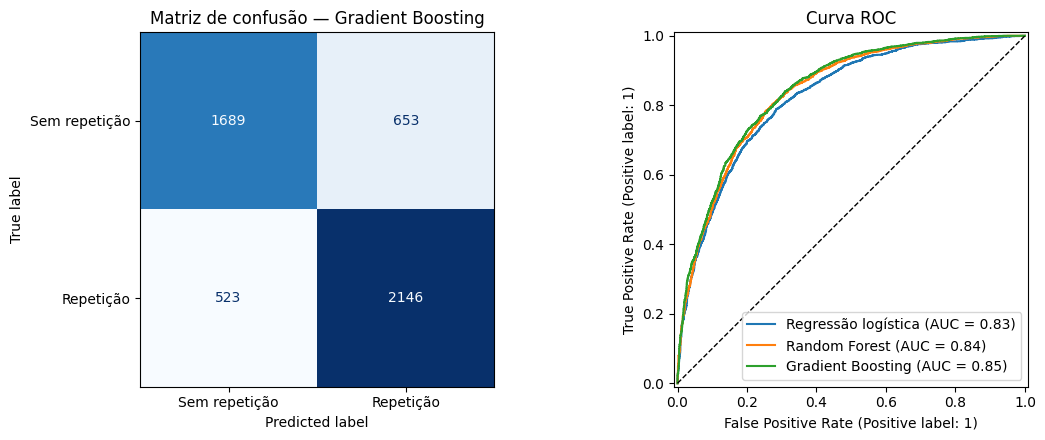

In [19]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report)
import matplotlib.pyplot as plt

best_name = comparison[comparison["modelo"] != "Baseline (Dummy)"].iloc[0]["modelo"]
best_model = trained[best_name]

baseline_auc = comparison.loc[comparison["modelo"] == "Baseline (Dummy)", "AUC"].iloc[0]
best_auc = comparison.loc[comparison["modelo"] == best_name, "AUC"].iloc[0]

print(f"Melhor modelo: {best_name}  (AUC {best_auc})")
print(f"Baseline     : AUC {baseline_auc}")

if best_auc <= baseline_auc + 0.02:
    print("\n[AVISO] O modelo NÃO supera o baseline de forma relevante.")
else:
    print(f"\n[INFO] Ganho sobre o baseline: {best_auc - baseline_auc:+.3f}")
print()

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred,
                            target_names=["Sem repetição", "Repetição"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Sem repetição", "Repetição"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matriz de confusão — {best_name}")

for name, pipe in trained.items():
    if name == "Baseline (Dummy)":
        continue
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)

axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Acaso")
axes[1].set_title("Curva ROC")
plt.tight_layout()


---
## 7. Validação

Fazendo permutation importance, ou seja, embaralhando uma variável por vez e medindo quanto o AUC cai. Se cair muito, a variável influênciava na decisão do AUC.

E depois verificando se algum campo sensível não entrou no modelo.

,variável,nome,queda no AUC,desvio
42,Autor — desconhecido,Autor — desconhecido,0.0214,0.0020
14,Violência psicológica/moral,Violência psicológica/moral,0.0188,0.0030
3,Local de ocorrência,Local de ocorrência,0.0160,0.0011
34,Autor — filho(a),Autor — filho(a),0.0151,0.0020
4,Possui deficiência ou transtorno,Possui deficiência ou transtorno,0.0149,0.0012
23,Meio — ameaça,Meio — ameaça,0.0142,0.0021
33,Suspeita de uso de álcool pelo autor,Suspeita de uso de álcool pelo autor,0.0141,0.0010
13,Violência física,Violência física,0.0139,0.0013
12,Violência motivada por,Violência motivada por,0.0103,0.0010
32,Sexo do provável autor,Sexo do provável autor,0.0086,0.0007


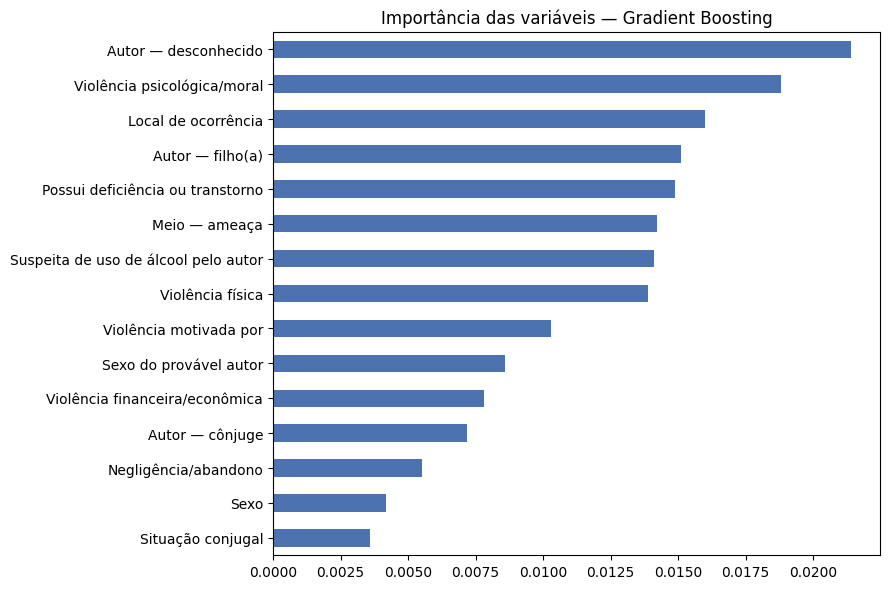

In [20]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1,
)

ranking = pd.DataFrame({
    "variável": X_test.columns,
    "nome": [LABELS.get(c, c) for c in X_test.columns],
    "queda no AUC": importance.importances_mean.round(4),
    "desvio": importance.importances_std.round(4),
}).sort_values("queda no AUC", ascending=False)

top = ranking.head(15).sort_values("queda no AUC")

ax = top.plot(kind="barh", x="nome", y="queda no AUC", figsize=(9, 6),
              color="#4C72B0", legend=False,
              title=f"Importância das variáveis — {best_name}")
ax.set_ylabel("")
plt.tight_layout()

ranking.head(20)

In [21]:
# Confirmar que nenhum campo de sensível entrou
leak = [c for c in X.columns if c.startswith(("ENC_", "DELEG_", "CONS_", "PROC_"))]

if leak:
  print("[AVISO] Encontrado campos sensíveis: ", leak)
else:
  print("[INFO] Nenhum campo de sensível encontrado.")

[INFO] Nenhum campo de sensível encontrado.


---
## 8. Exportar o modelo
Exportar o modelo com `.joblib` guardando o pipeline inteiro. O metadado ao lado registra o que foi treinado, com quais dados e qual desempenho.

In [22]:
import joblib
import json
from datetime import date
import sklearn

MODEL_FILE = f"modelo_risco_recorrencia_{YEAR}.joblib"
META_FILE = f"modelo_risco_recorrencia_{YEAR}_metadados.json"

joblib.dump(best_model, MODEL_FILE)

metadata = {
    "modelo": best_name,
    "data_treino": str(date.today()),
    "base": f"SINAN/VIOL {YEAR} — DATASUS",
    "populacao": f"vítimas {MINIMAL_AGE}+, violência interpessoal",
    "alvo": TARGET,
    "n_treino": int(len(X_train)),
    "n_teste": int(len(X_test)),
    "n_variaveis": int(X.shape[1]),
    "n_features_apos_encoding": int(n_features),
    "taxa_recorrencia": round(float(y.mean()), 4),
    "metricas": comparison[comparison["modelo"] == best_name].to_dict("records")[0],
    "variaveis_excluidas": DELETE,
    "versao_sklearn": sklearn.__version__,
    "aviso_uso": (
        "Ferramenta de apoio à triagem humana. Não substitui avaliação profissional e não deve excluir nenhum caso do atendimento."
    ),
}

with open(META_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Modelo   : {MODEL_FILE}")
print(f"Metadados: {META_FILE}")

# Teste de carga para garantir que o arquivo abre e prevê
reloaded = joblib.load(MODEL_FILE)
check = reloaded.predict_proba(X_test.head(3))[:, 1]
print(f"\n[INFO] Teste de carga OK — probabilidades: {check.round(3)}")




Modelo   : modelo_risco_recorrencia_2024.joblib
Metadados: modelo_risco_recorrencia_2024_metadados.json

[INFO] Teste de carga OK — probabilidades: [0.119 0.684 0.899]


In [23]:
# Baixar os arquivos
from google.colab import files

files.download(MODEL_FILE)
files.download(META_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>